# Part 24: Signal Construction and Long-Short Portfolios


Parts 22 and 23 focused on constructing and screening candidate predictors.
The next task is to map a selected feature set into a trading rule.

A feature is not yet a signal.
A signal is a rule for ranking opportunities or assigning positions.
The same feature can produce very different portfolios depending on how it is standardized, combined, and rebalanced.

In this Part we use a simple cross-sectional example to illustrate this transition from features to positions.


**Exercise.** Give an example of a quantity that is useful as a feature but not yet well defined as a trading signal.
What additional choices are needed before it becomes a portfolio rule?


<div class="lecture-pagebreak"></div>

## Basic Terms

We use the following terms in this Part.

A **signal** is a rule that maps observed data into a trading score or position.
A **rebalance date** is a date at which the signal is recomputed and the portfolio is updated.
The **long leg** consists of the assets receiving positive weight.
The **short leg** consists of the assets receiving negative weight.
**Turnover** measures how much the portfolio weights change from one rebalance date to the next.

We also distinguish between:

1. **Cross-sectional signals:** rank many assets at the same time.
2. **Time-series signals:** evaluate one asset relative to its own history.

The example below is cross-sectional.


**Exercise.** Why might a feature that works well in a regression problem still perform poorly when translated into a long-short portfolio?


<div class="lecture-pagebreak"></div>

## Why the Mapping Matters

Once a feature has been selected, several additional choices remain.

1. Should the feature be standardized within each date?
2. Should multiple features be combined additively or in some other way?
3. Should the strategy hold the strongest names only, or all names with varying weights?
4. How often should the portfolio rebalance?
5. How should turnover and implementation cost be handled?

These are portfolio-design choices rather than feature-engineering choices, but they materially affect the final result.

## A Simple Workflow

A practical sequence is the following.

1. Choose a universe and a rebalance schedule.
2. Compute feature values using only information available at the rebalance date.
3. Standardize or rank the features cross-sectionally.
4. Combine the selected features into a composite signal.
5. Map the signal into long and short weights.
6. Evaluate return, volatility, Sharpe ratio, and turnover.


<div class="lecture-pagebreak"></div>

## Example: A Monthly Long-Short Signal

For illustration we use a small universe of large US equities.
This is a convenience sample, not a survivorship-free universe.
The point is to illustrate the mechanics of signal formation rather than to make strong claims about a production strategy.

We construct three monthly ingredients.

1. Medium-horizon momentum.
2. Shorter-horizon momentum.
3. Volatility and drawdown penalties.

We then combine these into a composite cross-sectional score and form an equal-weight long-short portfolio.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lecture_utils import download_adjusted_close_panel


In [2]:
UNIVERSE = ['AAPL', 'MSFT', 'AMZN', 'GOOG', 'META', 'NVDA', 'JPM', 'XOM', 'JNJ', 'UNH', 'PG', 'HD']
START = '2016-01-01'
END = '2026-03-01'

adj_close = download_adjusted_close_panel(UNIVERSE, START, END)
adj_close.tail()


,AAPL,AMZN,GOOG,HD,JNJ,JPM,META,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,,,
2026-02-23,266.179993,205.270004,311.470581,374.486328,244.539993,297.670013,637.250000,384.470001,191.539642,165.169998,280.161926,150.759995
2026-02-24,272.140015,208.559998,310.701141,381.926605,246.279999,297.299988,639.299988,389.000000,192.839569,165.279999,271.836670,149.259995
2026-02-25,274.230011,210.639999,312.809631,373.075775,245.169998,303.299988,653.690002,400.600006,195.549408,163.389999,282.007599,149.059998
2026-02-26,272.950012,207.919998,306.933777,372.598938,243.470001,306.130005,657.010010,401.720001,184.879990,163.750000,284.448608,148.539993
2026-02-27,264.179993,210.000000,311.210754,378.191559,248.429993,300.299988,648.179993,392.739990,177.180420,167.199997,291.007599,152.500000


### Monthly Features

We compute the daily features first and then sample them at month end.
This ensures that the signal at each rebalance date depends only on information available at that time.


In [3]:
daily_ret = adj_close.pct_change()
mom_12m = adj_close.pct_change(252)
mom_3m = adj_close.pct_change(63)
vol_3m = daily_ret.rolling(63).std() * np.sqrt(252)
drawdown_6m = adj_close / adj_close.rolling(126).max() - 1

features_monthly = {
    'mom_12m': mom_12m.resample('ME').last(),
    'mom_3m': mom_3m.resample('ME').last(),
    'vol_3m': vol_3m.resample('ME').last(),
    'drawdown_6m': drawdown_6m.resample('ME').last(),
}

monthly_price = adj_close.resample('ME').last()
future_ret_1m = monthly_price.pct_change().shift(-1)
features_monthly['mom_12m'].tail()


,AAPL,AMZN,GOOG,HD,JNJ,JPM,META,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,,,
2025-10-31,0.162444,0.279778,0.653929,-0.016404,0.217911,0.425330,0.096259,0.207773,0.433969,-0.076732,-0.379205,0.010359
2025-11-30,0.202865,0.157707,0.897663,-0.147639,0.379927,0.277349,0.150196,0.183504,0.301652,-0.142711,-0.443867,0.001704
2025-12-31,0.068467,0.031598,0.623488,-0.102279,0.470423,0.364353,0.103969,0.131600,0.361587,-0.132329,-0.336772,0.171644
2026-01-31,0.088960,0.009406,0.723542,-0.071334,0.549496,0.170989,0.062483,-0.020043,0.545532,-0.061932,-0.453640,0.348942
2026-02-28,0.103892,-0.020294,0.789596,-0.000687,0.565807,0.184194,-0.034846,-0.009965,0.350080,0.002851,-0.351815,0.441072


### Signal Construction

The signal here is intentionally simple.
Higher momentum and milder drawdown receive higher rank.
Higher volatility receives lower rank.
The final signal is a weighted average of these cross-sectional ranks.


In [4]:
def cross_section_rank(df, ascending=True):
    return df.rank(axis=1, pct=True, ascending=ascending)


signal = (
    0.45 * cross_section_rank(features_monthly['mom_12m'], ascending=True)
    + 0.25 * cross_section_rank(features_monthly['mom_3m'], ascending=True)
    + 0.15 * cross_section_rank(features_monthly['drawdown_6m'], ascending=True)
    - 0.15 * cross_section_rank(features_monthly['vol_3m'], ascending=True)
)

signal = signal.dropna(how='all')
signal.tail()


,AAPL,AMZN,GOOG,HD,JNJ,JPM,META,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,,,
2025-10-31,0.470833,0.537500,0.737500,0.137500,0.508333,0.541667,0.095833,0.329167,0.566667,0.183333,0.141667,0.300000
2025-11-30,0.591667,0.300000,0.700000,0.066667,0.745833,0.554167,0.108333,0.383333,0.366667,0.212500,0.175000,0.345833
2025-12-31,0.425000,0.279167,0.712500,0.058333,0.741667,0.583333,0.154167,0.300000,0.387500,0.195833,0.091667,0.620833
2026-01-31,0.404167,0.350000,0.750000,0.162500,0.741667,0.458333,0.233333,0.095833,0.412500,0.354167,-0.058333,0.645833
2026-02-28,0.395833,0.125000,0.591667,0.437500,0.772917,0.400000,0.166667,0.070833,0.408333,0.552083,-0.045833,0.675000


### Portfolio Mapping

At each rebalance date, we buy the three highest-ranked names and short the three lowest-ranked names.
The portfolio is dollar-neutral by construction.


In [5]:
top_n = 3
bottom_n = 3

weights = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)

for dt in signal.index:
    row = signal.loc[dt].dropna().sort_values()
    if len(row) < top_n + bottom_n:
        continue
    short_names = row.index[:bottom_n]
    long_names = row.index[-top_n:]
    weights.loc[dt, long_names] = 1.0 / top_n
    weights.loc[dt, short_names] = -1.0 / bottom_n

aligned_future = future_ret_1m.reindex(weights.index)
portfolio_ret = (weights * aligned_future).sum(axis=1).dropna()
weights = weights.loc[portfolio_ret.index]

turnover = weights.diff().abs().sum(axis=1).div(2).fillna(0)
cumulative = (1 + portfolio_ret).cumprod()

summary = pd.DataFrame({
    'annualized_return': [12 * portfolio_ret.mean()],
    'annualized_volatility': [np.sqrt(12) * portfolio_ret.std()],
    'sharpe_like_ratio': [(12 * portfolio_ret.mean()) / (np.sqrt(12) * portfolio_ret.std())],
    'hit_rate': [(portfolio_ret > 0).mean()],
    'average_turnover': [turnover.mean()],
})
summary


,annualized_return,annualized_volatility,sharpe_like_ratio,hit_rate,average_turnover
0,0.056376,0.256579,0.219723,0.545455,0.693939


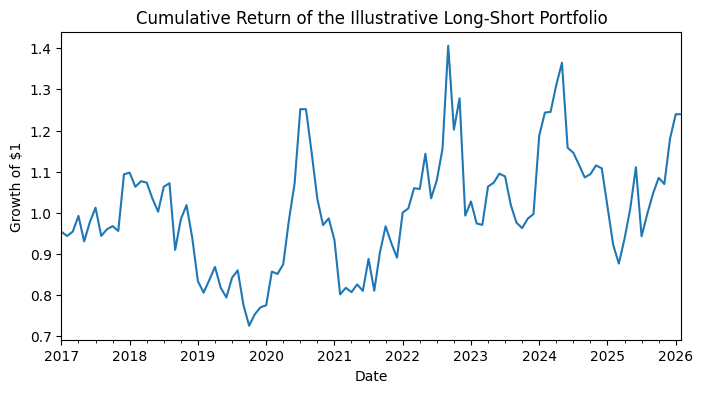

In [6]:
ax = cumulative.plot(figsize=(8, 4), title='Cumulative Return of the Illustrative Long-Short Portfolio')
ax.set_ylabel('Growth of $1')
plt.show()


**Exercise.** Which component of the signal above would you remove first if turnover were the primary concern? Explain your reasoning.


<div class="lecture-pagebreak"></div>

## Interpreting the Example

Several caveats are important.

1. The universe is small and survivorship-biased.
2. No transaction cost model has been applied.
3. The weights are intentionally simple.
4. The signal weights were chosen for illustration rather than by a formal estimation procedure.

Even so, the example highlights the main distinction between a feature and a portfolio rule.
A feature is a candidate piece of information. A signal specifies how that information is translated into a ranking and then into positions.

## Signals in the LOB Setting

The same logic applies at shorter horizons.
A model of next-price direction or a short-horizon imbalance measure is not yet a trading rule.
One still needs to specify thresholds, inventory controls, latency assumptions, and a mapping from model output to actual orders.


## Exercises

**Exercise 1.** Modify the signal so that the long and short legs each contain five assets rather than three. How does turnover change?

**Exercise 2.** Replace the equal-weight portfolio rule with weights proportional to the distance of each score from the cross-sectional median. What practical issues arise?

**Exercise 3.** Suppose that the signal is computed using month-end prices but implemented at the close of the same day. Why might this introduce bias?

**Exercise 4.** Give an example of a feature that may be useful for stock selection but difficult to convert into a stable long-short signal.


## References

1. Grinold and Kahn, *Active Portfolio Management*.
2. Jegadeesh and Titman (1993), *Returns to Buying Winners and Selling Losers*.
3. Cochrane, *Asset Pricing*.
4. Lopez de Prado (2018), *Advances in Financial Machine Learning*.
